In [1]:
using DifferentialEquations
using JumpProcesses
using Plots

using Statistics
using Distributions
using Random
using JLD2

using CSV
using DataFrames
using DelimitedFiles

using KernelDensity


# include own module with functionalities, ATTENTION, this will include StatsPlots
include("functionalities.jl")


# set seed for reproducibility
Random.seed!(123);

# Survival time distributions

In this notebokk we investigate a bit the structure of the overall survival times we simulated and which distributions are fitting them the best. For this purpose we first fit them to simple exponential distributions, to show that they are not exponentiall distributed. Afterwards we fit them to a generalized Gamma distribution explicitly accounting for the right-censored data points.

In [2]:
θ_old = [0.5, 0.01, 0.003, 0.03, 1.0, 0.001, 0.002];
θ_gompertz = [150000, 0.2, 0.01, 0.001, 0.0003, 0.003];
θ_treated = [0.5, 0.45, 0.2, 0.01, 0.003, 0.001, 0.002];

In [3]:
npat = 500
data_path = joinpath(pwd(),"data/simplified_model/proportional_data_$(npat)_patients_$(θ_old).jld2")
proportional_data = load(data_path)["proportional_data"];

In [4]:
npat = 500
gompertz_data= load("data/simplified_model/gompertz_data_$(npat)_patients_$(θ_gompertz).jld2")["gompertz_data"];

In [5]:
npat = 500
data_path = joinpath(pwd(),"data/simplified_model/cell_division_data_$(npat)_patients_$(θ_old).jld2")
cell_division_data = load(data_path)["cell_division_data"];

In [6]:
# load the data
npat = 1000
data_path = joinpath(pwd(),"data/simplified_model/additive_treated_data_$(npat)_patients_$(θ_treated).jld2")
treated_data = load(data_path)["additive_treated_data"];

Let us first plot them.

In [7]:
prop_kde = kde(proportional_data[proportional_data.death .== 1, :time])
plt = plot(prop_kde.x, prop_kde.density, label=false)
histogram!(plt, proportional_data[proportional_data.death .== 1, :time], normalize=:pdf, alpha=0.5, label=false)
plot!(plt, xlabel="Time", ylabel="Density",  tickfontsize=14, labelfontsize=14)
savefig(plt, "figures/surv_times_proportional_model.pdf")

"/home/vincent/PhD/Projects/method_project/ode_based_models/figures/ode_paper/surv_times_proportional_model.pdf"

In [8]:
prop_kde = kde(gompertz_data[gompertz_data.death .== 1, :time])
plt = plot(prop_kde.x, prop_kde.density, label=false)
histogram!(plt, gompertz_data[gompertz_data.death .== 1, :time], normalize=:pdf, alpha=0.5, label=false)
plot!(plt, xlabel="Time", ylabel="Density",  tickfontsize=14, labelfontsize=14)
savefig(plt, "figures/surv_times_gompertz_model.pdf")

"/home/vincent/PhD/Projects/method_project/ode_based_models/figures/ode_paper/surv_times_gompertz_model.pdf"

In [9]:
prop_kde = kde(cell_division_data[cell_division_data.death .== 1, :time])
plt = plot(prop_kde.x, prop_kde.density, label=false)
histogram!(plt, cell_division_data[cell_division_data.death .== 1, :time], normalize=:pdf, alpha=0.5, label=false)
plot!(plt, xlabel="Time", ylabel="Density", tickfontsize=14, labelfontsize=14)
savefig(plt, "figures/surv_times_cell_division_model.pdf")

"/home/vincent/PhD/Projects/method_project/ode_based_models/figures/ode_paper/surv_times_cell_division_model.pdf"

In [10]:
prop_kde = kde(treated_data[treated_data.death .== 1, :time])
plt = plot(prop_kde.x, prop_kde.density, label=false)
histogram!(plt, treated_data[treated_data.death .== 1, :time], normalize=:pdf, alpha=0.5, label=false)
plot!(plt, xlabel="Time", ylabel="Density", tickfontsize=14, labelfontsize=14)

savefig(plt, "figures/surv_times_treatment_model.pdf")

"/home/vincent/PhD/Projects/method_project/ode_based_models/figures/ode_paper/surv_times_treatment_model.pdf"

## Fitting Weibull and generalized Gamma distribution
To investigate, which distribution we see, we fit a generalized Gamma onto the different survival time datasets.

We will do MLE for that and later use Q-Q plots of Xi² goodness of fit tests. The qq plots is implementedin StatsPlots.

In the Julia package implementation we have as Weibull parameters $\alpha, \beta$ which corresponds to $\lambda, k$ in the paper.

In [7]:
using HypothesisTests
using Distributions, Random
using StatsPlots, StatsBase
using Survival

## Fitting distributions MLE Exponential and Weibull

In [14]:
proportional_surv_times = proportional_data[proportional_data.death .== 1, :time];

prop_fit_Exponential = fit_mle(Exponential, proportional_surv_times)
prop_fit_Weibull = fit_mle(Weibull, proportional_surv_times)

Weibull{Float64}(α=7.1330557719904775, θ=25.916146116614392)

In [ ]:
qqplot(proportional_surv_times, prop_fit_Exponential)

In [15]:
gompertz_surv_times = gompertz_data[gompertz_data.death .== 1, :time];

gompertz_fit_Exponential = fit_mle(Exponential, gompertz_surv_times)
gompertz_fit_Weibull = fit_mle(Weibull, gompertz_surv_times)

Weibull{Float64}(α=3.2858693730128232, θ=19.376243849387574)

In [ ]:
qqplot(gompertz_surv_times, gompertz_fit_Exponential)

In [18]:
ExactOneSampleKSTest(gompertz_surv_times, gompertz_fit_Weibull)

┌ Warning: This test is inaccurate with ties
└ @ HypothesisTests /home/vincent/.julia/packages/HypothesisTests/4N1Zy/src/kolmogorov_smirnov.jl:68


Exact one sample Kolmogorov-Smirnov test
----------------------------------------
Population details:
    parameter of interest:   Supremum of CDF differences
    value under h_0:         0.0
    point estimate:          0.0313651

Test summary:
    outcome with 95% confidence: fail to reject h_0
    two-sided p-value:           0.7697

Details:
    number of observations:   438


In [16]:
cell_division_surv_times = cell_division_data[cell_division_data.death .== 1, :time];

cell_division_fit_Exponential = fit_mle(Exponential, cell_division_surv_times)
cell_division_fit_Weibull = fit_mle(Weibull, cell_division_surv_times)

Weibull{Float64}(α=6.908568166876757, θ=25.8926767743479)

In [ ]:
qqplot(cell_division_surv_times, cell_division_fit_Exponential)

In [17]:
treated_surv_times = treated_data[treated_data.death .== 1, :time];

treated_fit_Exponential = fit_mle(Exponential, treated_surv_times)
treated_fit_Weibull = fit_mle(Weibull, treated_surv_times)

Weibull{Float64}(α=6.533528609469249, θ=25.62180004223494)

In [ ]:
qqplot(treated_surv_times, treated_fit_Exponential)

Exponential distribution is completely not fitting the data.

The Gompertz data seems most close to something that is Weibull distributed with not too crazy parameters and having nice fitting qqplots. For the others a generalized Gamma will work better.

## Fitting MLE generalized Gamma

In [8]:
using Revise
include("GeneralizedGammaDistribution.jl")
import .GeneralizedGammaDistribution as GGD

In [9]:
function censored_llh(data, dist)
    censored = data[data.Event .== 0, :Time]
    uncensored = data[data.Event .== 1, :Time]
    censored_lhood = sum(log.(1 .-cdf.(dist, censored)))
    uncensored_lhood = sum(log.(pdf.(dist, uncensored)))
    return censored_lhood + uncensored_lhood
end

function ggd_llh(par, data)
    a, d, p= par
    ggd_dist = GGD.GeneralizedGamma(GGD.WikipediaParams, a, d, p)
    try 
        global llh = censored_llh(data, ggd_dist)
    catch e
        global llh = -Inf
    end
    return llh
end

ggd_llh (generic function with 1 method)

### Exponential proportional model

In [18]:
proportional_surv_data = DataFrame(Time = proportional_surv_times, Event = ones(length(proportional_surv_times)))
# add censored data
n_survived = count(proportional_data.time .== 30.0)
proportional_surv_data = vcat(proportional_surv_data, DataFrame(Time = 30*ones(n_survived), Event = zeros(n_survived)));

In [19]:
GGDOptim = OptimizationFunction((x,p) -> -ggd_llh(x, proportional_surv_data), Optimization.AutoForwardDiff())
GGDOptimProblem = OptimizationProblem(GGDOptim, [2.0, 1.0, 2.0], lb=[1e-4, 1e-4, 1e-4], ub=[100, 100, 100])
GGDEst = solve(GGDOptimProblem, SAMIN(), maxiters=10^6, maxtime=300.0)

retcode: Failure
u: 3-element Vector{Float64}:
  4.52470371721091
 19.467291236858095
 30.92428873224325

In [20]:
# pars in wikipedia notation [a, d, p]
est_par = GGDEst.u
est_ggd = GGD.GeneralizedGamma(GGD.WikipediaParams, est_par[1], est_par[2], est_par[3]);

In [63]:
km_est = fit(KaplanMeier, proportional_surv_data.Time, proportional_surv_data.Event)
plt = plot(km_est.events.time,km_est.survival, label="KM", lw=2)
plot!(plt, 0:35, x -> 1-cdf(est_ggd, x), label="Generalized Gamma fit", ylimit=(0,1), lw=2)

plot!(plt, legendfontsize=12, guidefontsize=12, tickfontsize=12, legend=:bottomleft)
savefig(plt, "figures/ode_paper/surv_distribution_proportional.pdf")

"/home/vincent/PhD/Projects/method_project/ode_based_models/figures/ode_paper/surv_distribution_proportional.pdf"

### Cell-division model

In [57]:
cell_division_surv_data = DataFrame(Time = cell_division_surv_times, Event = ones(length(cell_division_surv_times)))
# add censored data
n_survived = count(cell_division_data.time .== 30.0)
cell_division_surv_data = vcat(cell_division_surv_data, DataFrame(Time = 30*ones(n_survived), Event = zeros(n_survived)));

In [ ]:
cell_division_GGDOptim = OptimizationFunction((x,p) -> -ggd_llh(x, cell_division_surv_data), Optimization.AutoForwardDiff())
cell_division_GGDOptimProblem = OptimizationProblem(cell_division_GGDOptim, [2.0, 1.0, 2.0], lb=[1e-4, 1e-4, 1e-4], ub=[100, 100, 100])
cell_division_GGDEst = solve(cell_division_GGDOptimProblem, SAMIN(), maxiters=10^6, maxtime=300.0)

In [66]:
# pars in wikipedia notation [a, d, p]
cell_division_est_par = cell_division_GGDEst.u
cell_division_est_ggd = GGD.GeneralizedGamma(GGD.WikipediaParams, cell_division_est_par[1], cell_division_est_par[2], cell_division_est_par[3]);

cell_division_km_est = fit(KaplanMeier, cell_division_surv_data.Time, cell_division_surv_data.Event)
plt = plot(cell_division_km_est.events.time,cell_division_km_est.survival, label="KM", lw=2)
plot!(plt, 0:35, x -> 1-cdf(cell_division_est_ggd, x), label="Generalized Gamma fit", ylimit=(0,1), lw=2)

plot!(plt, legendfontsize=12, guidefontsize=12, tickfontsize=12, legend=:bottomleft)
savefig(plt, "figures/ode_paper/surv_distribution_cell_division.pdf")

"/home/vincent/PhD/Projects/method_project/ode_based_models/figures/ode_paper/surv_distribution_cell_division.pdf"

### Treated data

In [49]:
treated_surv_data = DataFrame(Time = treated_surv_times, Event = ones(length(treated_surv_times)))
# add censored data
n_survived = count(treated_data.time .== 30.0)
treated_surv_data = vcat(treated_surv_data, DataFrame(Time = 30*ones(n_survived), Event = zeros(n_survived)));

In [ ]:
treated_GGDOptim = OptimizationFunction((x,p) -> -ggd_llh(x, treated_surv_data), Optimization.AutoForwardDiff())
treated_GGDOptimProblem = OptimizationProblem(treated_GGDOptim, [2.0, 1.0, 2.0], lb=[1e-4, 1e-4, 1e-4], ub=[100, 100, 100])
treated_GGDEst = solve(treated_GGDOptimProblem, SAMIN(), maxiters=10^6, maxtime=300.0)

In [ ]:
# pars in wikipedia notation [a, d, p]
treated_est_par = treated_GGDEst.u
treated_est_ggd = GGD.GeneralizedGamma(GGD.WikipediaParams, treated_est_par[1], treated_est_par[2], treated_est_par[3]);

treated_km_est = fit(KaplanMeier, treated_surv_data.Time, treated_surv_data.Event)
plt = plot(treated_km_est.events.time,treated_km_est.survival, label="KM", lw=2)
plot!(plt, 0:35, x -> 1-cdf(treated_est_ggd, x), label="Generalized Gamma fit", ylimit=(0,1), lw=2)
plot!(plt, legendfontsize=12, guidefontsize=12, tickfontsize=12, legend=:bottomleft)
# savefig(plt, "figures/ode_paper/surv_distribution_treated.pdf")

"/home/vincent/PhD/Projects/method_project/ode_based_models/figures/ode_paper/surv_distribution_treated.pdf"

# Real-data
Using survival data from some clinical trial, that were reported to be fitting with Gompertz(2.77, 28.84).\
The trial is named ACT2, and we use the KRAS-muation arm mut_c consisting of 33 patients.

In [22]:
act2_dataA = CSV.read("data/validation_data/ACT2_2A.csv", DataFrame)
act2_dataB = CSV.read("data/validation_data/ACT2_2B.csv", DataFrame)
act2_dataC = CSV.read("data/validation_data/ACT2_2C.csv", DataFrame)
act2_dataD = CSV.read("data/validation_data/ACT2_2D.csv", DataFrame)

act2_data = vcat(act2_dataA, act2_dataB, act2_dataC, act2_dataD)
act2_mutcB = act2_dataB[act2_dataB.Arm .== "mut_c", :]
act2_mutcD = act2_dataD[act2_dataD.Arm .== "mut_c", :]
act2_mutc = act2_data[act2_data.Arm .== "mut_c", :]
act2_mutc_death_times = act2_mutc[act2_mutc.Event .== 1, :Time];

### Censored data Weibull MLE

To fit the data, we need to implement a MLE based distribution fitting for right-censored data.

In [24]:
function censored_llh(data, dist)
    censored = data[data.Event .== 0, :Time]
    uncensored = data[data.Event .== 1, :Time]
    censored_lhood = sum(log.(1 .-cdf.(dist, censored)))
    uncensored_lhood = sum(log.(pdf.(dist, uncensored)))
    return censored_lhood + uncensored_lhood
end

function censored_weibull_llh(alpha, beta, data)
    dist = Weibull(alpha, beta)
    return censored_llh(data, dist)
end

censored_weibull_llh (generic function with 1 method)

In [25]:
act2_mutc_surv_times = act2_mutc[act2_mutc.Event .== 1, :Time];
act2_fit_Weibull = fit_mle(Weibull, act2_mutc_surv_times)

Weibull{Float64}(α=1.110751283716685, θ=13.704446456549382)

In [ ]:
WeibullOptim = OptimizationFunction((x,p) -> -censored_weibull_llh(x[1], x[2], act2_mutc), Optimization.AutoForwardDiff())
WeibullOptimProblem = OptimizationProblem(WeibullOptim, [2.0, 20], lb=[1e-4, 1e-4], ub=[10, 100])
WeibullEst = solve(WeibullOptimProblem, LBFGS(), maxiters=10^5, maxtime=300.0)

In [27]:
act2_mutcD_surv_times = act2_mutcD[act2_mutcD.Event .== 1, :Time];
act2_fit_Weibull = fit_mle(Weibull, act2_mutcD_surv_times)

Weibull{Float64}(α=2.8771006430877186, θ=26.102467467830433)

In [ ]:
WeibullOptim = OptimizationFunction((x,p) -> -censored_weibull_llh(x[1], x[2], act2_mutcD), Optimization.AutoForwardDiff())
WeibullOptimProblem = OptimizationProblem(WeibullOptim, [2.0, 20], lb=[1e-4, 1e-4], ub=[10, 100])
WeibullEst = solve(WeibullOptimProblem, LBFGS(), maxiters=10^5, maxtime=300.0)

In [29]:
gompertz_surv_data = DataFrame(Time = gompertz_surv_times, Event = ones(length(gompertz_surv_times)))
# add censored data
n_survived = count(gompertz_data.time .== 30.0)
gompertz_surv_data = vcat(gompertz_surv_data, DataFrame(Time = 30*ones(n_survived), Event = zeros(n_survived)));

In [ ]:
WeibullOptim = OptimizationFunction((x,p) -> -censored_weibull_llh(x[1], x[2], gompertz_surv_data), Optimization.AutoForwardDiff())
WeibullOptimProblem = OptimizationProblem(WeibullOptim, [2.0, 20], lb=[1e-4, 1e-4], ub=[10, 100])
WeibullEst = solve(WeibullOptimProblem, LBFGS(), maxiters=10^5, maxtime=300.0)

They are not that far away, but can I get them to match is the question.

In [ ]:
fit_dist = Weibull(WeibullEst.minimizer[1], WeibullEst.minimizer[2])

km_est = fit(KaplanMeier, gompertz_surv_data.Time, gompertz_surv_data.Event)
plt = plot(km_est.events.time,km_est.survival, label="KM", lw=2)
plot!(plt, 0:35, x -> ccdf(fit_dist, x), label="Weibull fit", ylimit=(0,1), lw=2)
plot!(plt, legendfontsize=12, guidefontsize=12, tickfontsize=12)
# savefig(plt, "figures/ode_paper/surv_distribution_gompertz.pdf")

"/home/vincent/PhD/Projects/method_project/ode_based_models/figures/ode_paper/surv_distribution_gompertz.pdf"

Lets test the equality of the distributions.

In [ ]:
nbins = 10
bins1 = quantile(gompertz_surv_times, LinRange(1/nbins,1,nbins))
h1 = fit(Histogram, gompertz_surv_times, bins1)
fd1 = fit(Weibull,gompertz_surv_times)
theta1 = diff(cdf.(fd1,bins1))
ChisqTest(h1.weights, theta1/sum(theta1)) 

In [ ]:
PowerDivergenceTest(h1.weights, lambda=-2.0) 

In [ ]:
ExactOneSampleKSTest(gompertz_surv_times, fd1)

In [ ]:
OneSampleADTest(gompertz_surv_times, fd1)

Parametric and non-parametric tests cannot reject the hypothesis that the distributions are equal.

## Parameter search
Lets play a bit with the parameters of the gompertz model to get close to the real data.

In [32]:
include("general_MNR_simulation_algorithm.jl")

function GompertzODE!(du, u, p, t)
    du[1] = p[2] * u[1] * log(p[1]/u[1])
end
function TumorPath(S0, p; endtime=30.0)
    prob = ODEProblem(GompertzODE!, [S0], (0.0, endtime), [p.K, p.α])
    sol = solve(prob, Tsit5(), reltol=1e-8, abstol=1e-8)
    return sol
end

# set parameters
K = 100000
α = 0.15
S0 = 0.065
endtime = 30
p = (K=K, α=α, m_basal = 0.01, m_size = 0.001, d_size = 0.0003, d_metastasis = 0.003)

gompertz_df = simulate_many_MNR(p, TumorPath, S0 = S0, npat = 300);

In [ ]:
gompertz_surv_times = gompertz_df[gompertz_df.death .== 1, :time];
gompertz_surv_data = DataFrame(Time = gompertz_surv_times, Event = ones(length(gompertz_surv_times)))
# add censored data
n_survived = count(gompertz_df.time .== 30.0)
gompertz_surv_data = vcat(gompertz_surv_data, DataFrame(Time = 30*ones(n_survived), Event = zeros(n_survived)));

WeibullOptim = OptimizationFunction((x,p) -> -censored_weibull_llh(x[1], x[2], gompertz_surv_data), Optimization.AutoForwardDiff())
WeibullOptimProblem = OptimizationProblem(WeibullOptim, [2.0, 20], lb=[1e-4, 1e-4], ub=[10, 100])
WeibullEst = solve(WeibullOptimProblem, LBFGS(), maxiters=10^5, maxtime=300.0)

In [ ]:
act2_dataD = CSV.read("data/validation_data/ACT2_2D.csv", DataFrame)
act2_mutcD = act2_dataD[act2_dataD.Arm .== "mut_c", :]
act2_mutcD_surv_times = act2_mutcD[act2_mutcD.Event .== 1, :Time];

DataWeibullOptim = OptimizationFunction((x,p) -> -censored_weibull_llh(x[1], x[2], act2_mutcD), Optimization.AutoForwardDiff())
DataWeibullOptimProblem = OptimizationProblem(DataWeibullOptim, [2.0, 20], lb=[1e-4, 1e-4], ub=[10, 100])
DataWeibullEst = solve(DataWeibullOptimProblem, LBFGS(), maxiters=10^5, maxtime=300.0)

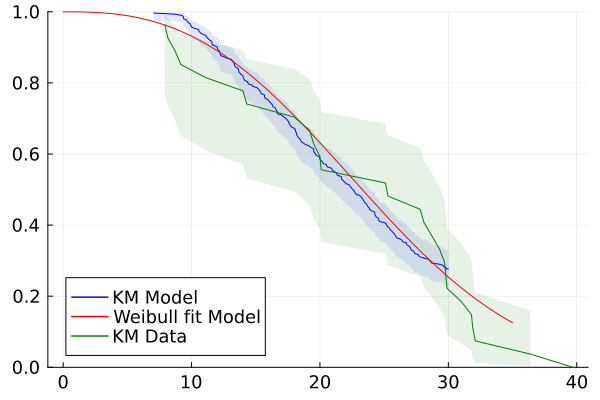

In [41]:
model_fit_dist = Weibull(WeibullEst.u[1], WeibullEst.u[2])
model_km_est = fit(KaplanMeier, gompertz_surv_data.Time, gompertz_surv_data.Event)
data_fit_dist = Weibull(DataWeibullEst.u[1], DataWeibullEst.u[2])
data_km_est = fit(KaplanMeier, act2_mutcD_surv_times, ones(length(act2_mutcD_surv_times)))


plt = plot(model_km_est.events.time, model_km_est.survival, label="KM Model", color="blue")
plot!(plt, model_km_est.events.time, [x[1] for x in confint(model_km_est)], fillrange=[x[2] for x in confint(model_km_est)], fillalpha=0.1, linealpha=0, color="blue", label=false)
plot!(plt, 0:35, x -> ccdf(model_fit_dist, x), label="Weibull fit Model", ylimit=(0,1), color="red")
plot!(plt, data_km_est.events.time, data_km_est.survival, label="KM Data", color="green")
plot!(plt, data_km_est.events.time, [x[1] for x in confint(data_km_est)], fillrange=[x[2] for x in confint(data_km_est)], fillalpha=0.1, linealpha=0, color="green", label=false)
plot!(plt, tickfontsize=12, legendfontsize=12)

# savefig(plt, "figures/ode_paper/real_data_gompertz_weibull_fit.pdf")
